This project aims to benchmark a simple linear regression model to a lasso regression model with hyperparameter search space,
by recreating the linear regression model that is introduced in MITx Supply Chain Management Micromasters / SC0x Supply Chain Analytics Course using the same underlying supply chain (transportation) data, BUT in two ways:

1. ML-1 (Linear Regression): Applying the same conditions (no scaling, etc.) to the model as applied in the course, except the possibilities of
    - second degree polynomial structure use with interactions allowed between features,
    - converting lead time into a ordinal / binary feature,
    - restriction of coefficients to being positive only.
2. ML-2 (Lasso Regression): Applying full-fledged hyperparametrization including polynomial degree, feature interaction, scaling and coefficient regularization.

**KEY FINDING:** ML-1, despite being simpler than the other, was slightly better that ML-2 on both train and test $R^2$ scores and residuals.

- ML-1 Train $R^2$ score: 0.83
- **ML-1 Test $R^2$ score: 0.72**
- **ML-1 Test $R^2$ score (adjusted): 0.71**

Note: "cpl" is the short for "Cost per Load" and it is the target feature in this project

# Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

plt.rc("axes.spines", top=False, right=False)
plt.style.use("ggplot")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Load data

In [2]:
df = pd.read_csv("duffy.csv")
df = df.drop(columns = "Number ID")

In [3]:
df.head()

,CPL,Dist,LdTime,TrlLng,Wgt,Equpt
0,3692,1579,1,53,20559,DRY
1,3279,1298,12,48,17025,REF
2,3120,1382,11,48,26735,DRY
3,3205,1033,1,53,26175,DRY
4,3188,1320,3,53,17994,DRY


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   CPL       100 non-null    int64
 1   Dist      100 non-null    int64
 2   LdTime    100 non-null    int64
 3    TrlLng   100 non-null    int64
 4   Wgt       100 non-null    int64
 5   Equpt     100 non-null    str  
dtypes: int64(5), str(1)
memory usage: 5.1 KB


## Manipulate Data

In [5]:
df.columns = ["cpl", "distance", "lead_time", "trail_length", "weight", "equipment"]
df["trail_length"] = df.trail_length.apply(lambda cell: 0 if cell == 48 else 1)
df["equipment"] = df.equipment.apply(lambda cell: 0 if cell == "DRY" else 1)

- Trail length and equipment values are rendered binary in a way to contribute to the cpl positively if 1.

## Multicollinearity check

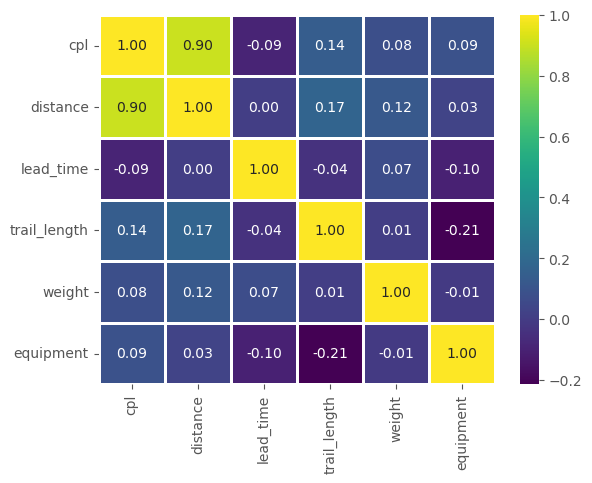

In [6]:
sns.heatmap(
	data=df.corr(),
	annot=True,
	fmt=".2f",
	ec="white",
	lw=1,
	cmap="viridis",
	snap=True
);

	- No multicollinearity issue between the features.

## Specific data manipulation 

In [7]:
df["lead_time1"] = -df.lead_time

- Lead_time will never be used in the models below at all. Instead, lead_time1 will be used.
- Lead_time1:  actual values are rendered negative to force ML models below to produce positive coefficients only.

In [8]:
df.head()

,cpl,distance,lead_time,trail_length,weight,equipment,lead_time1
0,3692,1579,1,1,20559,0,-1
1,3279,1298,12,0,17025,1,-12
2,3120,1382,11,0,26735,0,-11
3,3205,1033,1,1,26175,0,-1
4,3188,1320,3,1,17994,0,-3


## Features and target

In [9]:
x = df.drop(columns=["cpl", "lead_time"])
y = df.cpl

# Assumptions
1. All independent variables are necessary to be used in the models from the business logic perspective regardless of their parameter statistics. Explainability and prediction power are more significant in this regard.
2. The feature lead time is considered as ratio though the feature is discrete with only 13 unique entries. Because there is no meaningful and consistent change of slope in the graph below, "cpl by lead_time", that would indicate some sort of breakpoints to create categories upon.

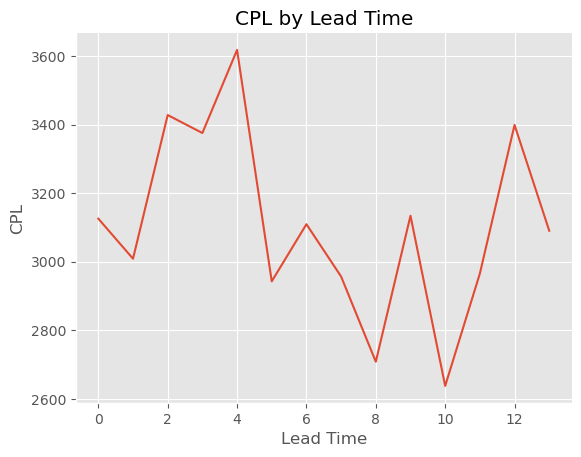

In [10]:
lead_time = df.groupby("lead_time")["cpl"].mean()
lead_time.plot.line(ylabel="CPL", xlabel="Lead Time", title="CPL by Lead Time");

# ML - 1
    Initial conditions
    - Polynomial degree: 2, NO scaling, Linear Regression model --> one that could be done in MS excel with some effort
    - Lead time is rendered negative above to force all coefficients to be positive below 
    - Scaling is not considered in order to ease explainability and refrain from unscaling in ML-1

## Train - test split

In [11]:
strats = df["trail_length"].astype(str) + "_" + df["equipment"].astype(str)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42, stratify=strats)

## Pipe

In [12]:
input_steps = [
	("pol", PolynomialFeatures(degree=1, include_bias=False)),
	("model", LinearRegression(positive=True))
]

pipe = Pipeline(input_steps)

## Cross Validation

In [13]:
results = cross_validate(
	pipe,
	x_train,
	y_train,
	cv=5,
	scoring="r2",
	return_estimator=True,
	return_train_score=True
)

train_scores = results["train_score"]
validation_scores = results["test_score"]

scores = pd.DataFrame({
	"train_scores": train_scores,
	"validation_scores": validation_scores}
)
display(scores)

print("Train scores average:", train_scores.mean())
print("Validation scores average:", validation_scores.mean())

print("Train scores standard deviation:", train_scores.std())
print("Validation scores standard deviation:", validation_scores.std())

,train_scores,validation_scores
0,0.817764,0.891624
1,0.819044,0.871906
2,0.833506,0.829748
3,0.850651,0.713806
4,0.858736,0.686125


Train scores average: 0.8359404663009282
Validation scores average: 0.7986417906035402
Train scores standard deviation: 0.016479484849093562
Validation scores standard deviation: 0.08347216606516682


## Interpretation before further steps

1. Variance of train scores is low. Data character should be the same in every part of data.
2. Variance of validation scores is moderate. Overfitting test:
- overfitting ratio = $\frac{\text{Score}_{\text{train}} - \bar{\text{Score}}_{\text{val}}}{\text{Score}_{\text{train}}}$

In [14]:
overfitting_ratio = [round((train_score - validation_scores.mean()) / train_score, 4) for train_score in train_scores]
display(pd.Series(overfitting_ratio).to_frame(name="Overfitting Ratios"))
print("Overfitting ratio average is: ", sum(overfitting_ratio) / len(overfitting_ratio))

,Overfitting Ratios
0,0.0234
1,0.0249
2,0.0418
3,0.0611
4,0.0700


Overfitting ratio average is:  0.04424


- overfitting ratio is less than 0.1 for all train scores and 0.05 in average. GOOD!.

- consistency ratio (CV) = $\frac{\sigma_{test scores}}{\mu_{test scores}}$

In [15]:
CV = validation_scores.std() / validation_scores.mean()
print("CV is: ", round(CV, 4))

CV is:  0.1045


- CV is 0.1. Just the threshold. GOOD!.

3. As CV sits just on the threshold, 0.1, the same model was run with polynomial degree 2. Comparison:

| Measure ($R^2$) | degree = 2 | degree = 1 | Remarks |
| :--- | :---: | :---: | :--- |
| Train Scores Average | 0.88 | 0.84 | better in degree=2 |
| Train Scores standard Deviation | 0.01 | 0.02 | better in degree=2 but still low |
| **Validation Scores Average** | 0.76 | **0.80** | better in degree=1 |
| Validation Scores Standard Deviation | 0.05 | 0.08 | better in degree=2 |
| Overfitting Ratio | 0.13 | 0.04 | better in degree=1 and less than 0.1 |
| CV | 0.07 | 0.1 | better in degree=2 but still within the limits |

4. The run results of degree=1 and binary lead time alternative (taken from a makeshift notebook) are below. The improvement is so slight, negligible.

| Measure ($R^2$) | degree = 1 | degree = 1 and binary lead time (0, 4) - ( >4) | Remarks |
| :--- | :---: | :---: | :--- |
| Train Scores Average | 0.8358 | 0.8373 | slightly better |
| Train Scores standard Deviation | 0.0165 | 0.163 | slightly better |
| Validation Scores Average | 0.7997 | 0.8031 | slightly better |
| Validation Scores Standard Deviation | 0.084 | 0.0803 | slightly better |
| Overfitting Ratio | 0.0428 | 0.0404 | slightly better |
| CV | 0.1050 | 0.0999 | slightly better |

## Decision
- Go with the degree=1 as this configuration provides less variance and better R2 score average in test scores with better generalization.

## Fit, coefficients, predict, residuals

In [16]:
pipe.fit(x_train, y_train)
coefs = pd.DataFrame({
	"features": pipe[:-1].get_feature_names_out(),
	"coefficients": pipe[-1].coef_
})
coefs

,features,coefficients
0,distance,1.553278
1,trail_length,0.000000
2,weight,0.000000
3,equipment,21.391564
4,lead_time1,22.145890


    - As seen, trail_length and weight have zero contribution to the cpl.

In [17]:
y_pred = pipe.predict(x_test)
y_pred_train = pipe.predict(x_train)
residuals = y_test - y_pred
print("Residuals average: ", residuals.mean())

Residuals average:  57.557197597135385


In [18]:
relative_bias = residuals.mean() / y_test.mean()
print("Relative bias: ", relative_bias)

Relative bias:  0.018494054879871276


In [19]:
test_r2 = r2_score(y_test, y_pred)
train_r2 = r2_score(y_train, y_pred_train)

print("Test R2 score: ", test_r2)
print("Train R2 score: ", train_r2)

Test R2 score:  0.7171949152213056
Train R2 score:  0.8347591369367391


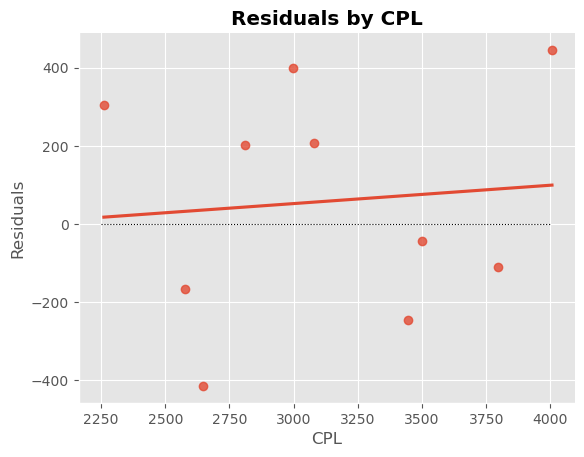

In [20]:
sns.regplot(y=residuals, x=y_test, order=1, ci=None)
plt.ylabel("Residuals")
plt.xlabel("CPL")
plt.title("Residuals by CPL", fontweight="bold")
plt.hlines(y=0, xmin=2250, xmax=4000, color="black", lw=0.8, ls=":");

### Residual validation

- Quantitative validation of residuals will not be performed as there are only 10 values.
- Though this is also not quite reasonable to perform, qualitative validation:
    - Normality: cannot be done either due to scarce data
    - Linearity: randomly dispersed 5 positive and 5 negative data points. Trendline above is misleading as standard error and variance is to be high with such scarce data: this is the reason behind the trendline's positive slope.
    - Independence: some negative auto correlation seems to exist
    - Equal variance: no variance change in residual values as the cpl values increased / decreased.

## Insights
- Residuals mean is NOT zero. However, given the observation count is only 100 and test size is 10; residuals could not have enough test size to settle down and reach consisteny.
- Moreover, relative bias (the ratio of average residuals to average target test values) is 1.8% only, less than 5%. That's acceptable.
- Test $R^2$ score is 72%, can be acceptable in supply chain management.

# ML - 2 (Hyperparametrization)
    - polynomial degrees
    - polynomial interaction between independent variables
    - scaling or NOT
    - regularization (alphas)

## Train Test Split
    - Will be used as it is in ML-1

## Pipe

In [21]:
input_steps = [
	("pol", PolynomialFeatures(include_bias=False)),
	("scaler", StandardScaler()),
	("model", LassoCV(alphas = np.logspace(-3, 3, 5), positive=True, max_iter=100000))
]

pipe = Pipeline(input_steps)

    - Intermediate Step : Hyperparameter Preparation

In [22]:
param_grid = [
	{
		"pol__degree": [1],
		"scaler": [StandardScaler(), "passthrough"]
	},
	{
		"pol__degree": [2, 3],
		"pol__interaction_only": [True, False],
		"scaler": [StandardScaler(), "passthrough"]
	}
]

grid_search = GridSearchCV(
	estimator=pipe,
	param_grid=param_grid,
	cv=5,
	scoring="r2",
	n_jobs=-1
)

## Cross Validation

In [23]:
results = cross_validate(
	grid_search,
	x_train,
	y_train,
	cv=5,
	scoring="r2",
	return_estimator=True,
	return_train_score=True,
	n_jobs=-1
)

In [24]:
train_scores = results["train_score"]
test_scores = results["test_score"]

pipes = []
degrees=[]
interactions=[]
scalings=[]
alphas=[]
for gs_instant in results["estimator"]:
	pipe_instant = gs_instant.best_estimator_
	pipes.append(pipe_instant)
	degrees.append(pipe_instant["pol"].degree)
	interactions.append(pipe_instant["pol"].interaction_only)
	scalings.append(pipe_instant["scaler"])
	alphas.append(pipe_instant["model"].alpha_)

scores = pd.DataFrame({
	"train_scores": train_scores,
	"validation_scores": test_scores,
	"pol_degree": degrees,
	"interaction_only": interactions,
	"scaling": scalings,
	"regularization": alphas}
)
display(scores.style.set_properties(subset=pd.IndexSlice[0:1, :], color="blue"))

print("Train scores average:", train_scores.mean())
print("Validation scores average:", test_scores.mean())

print("Train scores standard deviation:", train_scores.std())
print("Validation scores standard deviation:", test_scores.std())

,train_scores,validation_scores,pol_degree,interaction_only,scaling,regularization
0,0.829945,0.880792,2,True,passthrough,1000.000000
1,0.818798,0.875062,1,False,passthrough,31.622777
2,0.831176,0.839693,1,False,passthrough,31.622777
3,0.846754,0.694611,1,False,StandardScaler(),31.622777
4,0.852897,0.713999,1,False,StandardScaler(),31.622777


Train scores average: 0.835914037180191
Validation scores average: 0.800831256879268
Train scores standard deviation: 0.012304080549344992
Validation scores standard deviation: 0.0802955415997817


- As seen above, no benefit is acquired from the hyperparametrization, the scores are the same as / even worse than the ones obtained in the ML-1 linear regression.
- Nevertheless, we will continue with fitting the model here and prove that the best parameters yielding the results above are either the ones used in ML-1 linear regression model or contributing with near-zero coefficients if ever different.  

- GridSearchCV object selects the pipe / model with the best validation score, which is indexed 0 above. However, the model indexed 1 with the pol_degree=1 and the best validation score, without scaling might yield better results in terms of simplicity and interpretability. Therefore both of them will be tried out.

## Fit, coefficients, predict, residuals

> pipe0 is the one that gridsearch object selects, indexed 0 above and pipe1 is the alternative indexed 1 above

In [25]:
pipe0 = pipes[0]
pipe0.fit(x_train, y_train)
pipe1 = pipes[1]
pipe1.fit(x_train, y_train)

,steps,"[('pol', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,1
,interaction_only,False
,include_bias,False
,order,'C'
,eps,0.001
,n_alphas,'deprecated'
,alphas,array([1.0000...00000000e+03])


In [26]:
# best_pipe = grid_search.best_estimator_

coefs0 = pd.DataFrame({
	"features0": pipe0[:-1].get_feature_names_out(),
	"coefficients0": pipe0["model"].coef_
})

coefs1 = pd.DataFrame({
	"features1": pipe1[:-1].get_feature_names_out(),
	"coefficients1": pipe1["model"].coef_
})

print("First pipe:", "---" * 20, sep="\n")

degree = pipe0["pol"].degree
print("Best polynomial degree: ", degree)

interaction = pipe0["pol"].interaction_only
print("Interaction_only?: ", interaction)

scaling = pipe0["scaler"]
print("Scaling used?: ", scaling if not scaling=="passthrough" else False)

alpha = pipe0["model"].alpha_
print("Regularization used: ", round(alpha, 2))

print("\n", "Second pipe:", "---" * 20, sep="\n")

degree = pipe1["pol"].degree
print("Best polynomial degree: ", degree)

interaction = pipe1["pol"].interaction_only
print("Interaction_only?: ", interaction)

scaling = pipe1["scaler"]
print("Scaling used?: ", scaling if not scaling=="passthrough" else False)

alpha = pipe1["model"].alpha_
print("Regularization used: ", round(alpha, 2))

coefs = pd.merge(coefs0, coefs1, left_on="features0", right_on="features1", how="outer")
coefs

First pipe:
------------------------------------------------------------
Best polynomial degree:  2
Interaction_only?:  True
Scaling used?:  False
Regularization used:  1000.0


Second pipe:
------------------------------------------------------------
Best polynomial degree:  1
Interaction_only?:  False
Scaling used?:  False
Regularization used:  31.62


,features0,coefficients0,features1,coefficients1
0,distance,1.538236e+00,distance,1.555682
1,distance equipment,4.981273e-03,NaN,NaN
2,distance lead_time1,0.000000e+00,NaN,NaN
3,distance trail_length,2.959195e-03,NaN,NaN
4,distance weight,4.841829e-07,NaN,NaN
5,equipment,0.000000e+00,equipment,0.000000
6,equipment lead_time1,0.000000e+00,NaN,NaN
7,lead_time1,0.000000e+00,lead_time1,20.573708
8,trail_length,0.000000e+00,trail_length,0.000000
9,trail_length equipment,0.000000e+00,NaN,NaN


- As seen above, pipe0 is with the polynomial degree is 2 (not 1) but it is only used with interaction_only=True, no second degree standalone feature.
- These interactions are used but with zero or near-zero values.
- Trail length, weight and equipment are not used in pipe1.
- Scaling is not used in both pipe0 and pipe1 as it is in the ML-1.

In [27]:
y_pred0 = pipe0.predict(x_test)
y_pred1 = pipe1.predict(x_test)
y_pred_train0 = pipe0.predict(x_train)
y_pred_train1 = pipe1.predict(x_train)

In [28]:
residuals0 = y_test - y_pred0
residuals1 = y_test - y_pred1

In [29]:
print("Residuals 0 average: ", residuals0.mean())
print("Residuals 1 average: ", residuals1.mean())
relative_bias0 = residuals0.mean() / y_test.mean()
relative_bias1 = residuals1.mean() / y_test.mean()
print("Relative bias 0: ", relative_bias0)
print("Relative bias 1: ", relative_bias1)

Residuals 0 average:  86.56543233539045
Residuals 1 average:  56.01964215641378
Relative bias 0:  0.027814868046844823
Relative bias 1:  0.01800001354553492


- Residuals average and relative bias from pipe0 here are 1.65 times that of ML-1. BAD!.
- Residuals average and relative bias from pipe1 here are just the same values encountered in ML-1. Coefficients and parametrized features are slightly different from the ones in ML-1 as regularization is applied here.

In [30]:
test_r2_0 = r2_score(y_test, y_pred0)
test_r2_1 = r2_score(y_test, y_pred1)
train_r2_0 = r2_score(y_train, y_pred_train0)
train_r2_1 = r2_score(y_train, y_pred_train1)

print("Test R2 score 0: ", test_r2_0)
print("Test R2 score 1: ", test_r2_1)
print("Train R2 score 0: ", train_r2_0)
print("Train R2 score 1: ", train_r2_1)

Test R2 score 0:  0.6178583793494574
Test R2 score 1:  0.7114721880268005
Train R2 score 0:  0.842470507072685
Train R2 score 1:  0.8343746026776375


- Test R2 score 0 is >15% less than that of ML-1. BAD!.
- Again, test R2 score 1 is the same as that of ML-1: 72%

> The residual plot from pipe0:

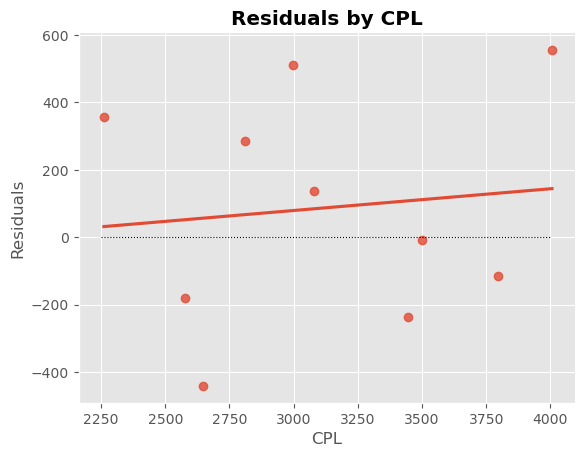

In [31]:
sns.regplot(y=residuals0, x=y_test, order=1, ci=None)
plt.ylabel("Residuals")
plt.xlabel("CPL")
plt.title("Residuals by CPL", fontweight="bold")
plt.hlines(y=0, xmin=2250, xmax=4000, color="black", lw=0.8, ls=":");

### Residual validation

- Quantitative validation of residuals will not be performed as there are only 10 values.
- Though this is also not quite reasonable to perform, qualitative validation:
    - Normality: cannot be done either due to scarce data
    - Linearity: randomly dispersed 5 positive and 5 negative data points. Trendline above is misleading as standard error and variance is to be high with such scarce data: this is the reason behind the trendline's positive slope.
    - Independence: some negative auto correlation seems to exist
    - Equal variance: no variance change in residual values as the cpl values increased / decreased.

# Final Word
The simpler the better:
- pipe0, the one with the best validation score in ML-2, could not defeat the linear regression model in ML-1.
- pipe1, the one with the second best validation score with degree=1 and unscaled in ML-2, performed almost the same as that of ML-1.  